In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torchvision.utils import save_image

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data',train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

def to_img(x):
    x = 0.5 * (x+1)
    x = x.clamp(0, 1)
    x = x.view(x.size(0), 1, 28, 28)
    return x

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:02<00:00, 3893517.44it/s]


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 152527.35it/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 1681293.06it/s]


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 4520770.95it/s]

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw



In [15]:
train_loader


In [53]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(True),
            nn.Linear(128, 64),
            nn.ReLU(True),
            nn.Linear(64, 12),
            nn.ReLU(True),
            nn.Linear(12, 3) #잠재 공간의 차원
        )

        # 디코더 부분
        self.decoder = nn.Sequential(
            nn.Linear(3, 12),
            nn.ReLU(True),
            nn.Linear(12, 64),
            nn.ReLU(True),
            nn.Linear(64, 128),
            nn.ReLU(True),
            nn.Linear(128, 28*28),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.NAdam(model.parameters(), lr=0.001)



In [55]:
num_epochs = 7
for epoch in range(num_epochs):
    for data in train_loader:
        img, _ =  data
        img = img.view(img.size(0), -1)
        img = img.to(device)

        # Forward pass
        output = model(img)
        loss = criterion(output, img)
        loss = criterion(output, img)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Log
    print('Epoch [{}/{}], Loss: {:.4f}'.format(epoch+1, num_epochs, loss.item()))

Epoch [1/7], Loss: 0.1549
Epoch [2/7], Loss: 0.1216
Epoch [3/7], Loss: 0.1380
Epoch [4/7], Loss: 0.1517
Epoch [5/7], Loss: 0.1449
Epoch [6/7], Loss: 0.1358
Epoch [7/7], Loss: 0.1247


In [56]:
# 시각화
if (epoch+1) % 10 == 0:
    pic = to_img(output.cpu().data)
    save_image(pic, './data/output_{}.png'.format(epoch+1))

In [62]:
# 테스트 이미지 로드 및 변환
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=10, shuffle=True)
test_images, _ = next(iter(test_loader))
test_images, _

(tensor([[[[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]]],
 
 
         [[[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]]],
 
 
         [[[-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           ...,
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.],
           [-1., -1., -1.,  ..., -1., -1., -1.]]],
 
 
         ...,
 
 
         [[[-1., -1., -1.,  ..., -

In [63]:
test_images = test_images.view(test_images.size(0), -1)
test_images = test_images.to(device)
test_images

tensor([[-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        ...,
        [-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.],
        [-1., -1., -1.,  ..., -1., -1., -1.]])

In [64]:
# 이미지 복원
reconstructed = model(test_images)
reconstructed = to_img(reconstructed.cpu().data)
reconstructed

tensor([[[[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          ...,
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00,
           0.0000e+00, 0.0000e+00]]],


        [[[3.9041e-06, 4.2915e-06, 2.8014e-06,  ..., 7.9870e-06,
           3.6359e-06, 1.4693e-05],
          [4.3809e-06, 4.7684e-06, 9.1195e-06,  ..., 7.4506e-06,
           5.1260e-06, 3.6359e-06],
          [4.3511e-06, 2.9504e-06, 5.5730e-06,  ..., 1.1772e-05,
           1.0997e-05, 1.4007e-05],
          ...,
          [1.0014e-05, 6.5565e-06, 5.7518e-06,  ..., 3.15

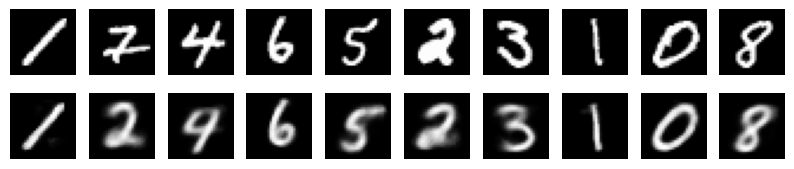

In [65]:
# 원본 및 복원 이미지 시각화
fig, axs = plt.subplots(2, 10, figsize=(10, 2))
for i in range(10):
    axs[0, i].imshow(test_images[i].view(28, 28).cpu(), cmap='gray')
    axs[0, i].axis('off')
    axs[1, i].imshow(reconstructed[i].view(28, 28), cmap='gray')
    axs[1, i].axis('off')
plt.show()

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 데이터셋 생성 함수
def create_sine_wave_data(data_size, freq=100):
    t = np.arange(data_size)
    return np.sin(2 * np.pi * freq * t / data_size)

# 데이터 생성
data_size = 1024 # 우리가 생성하고자하는 사인파 주파수 형을 만드는 크기 숫자
data = create_sine_wave_data(data_size)
data


array([ 0.        ,  0.57580819,  0.94154407, ..., -0.96377607,
       -0.94154407, -0.57580819])

In [8]:
# 텐서로 변환
data = torch.tensor(data, dtype=torch.float32)
data


tensor([ 0.0000,  0.5758,  0.9415,  ..., -0.9638, -0.9415, -0.5758])

Epoch 100/1000, Loss: 0.0002002071705646813
Epoch 200/1000, Loss: 0.00012790635810233653
Epoch 300/1000, Loss: 0.0001420496846549213
Epoch 400/1000, Loss: 0.00020340396440587938
Epoch 500/1000, Loss: 0.00015497341519221663
Epoch 600/1000, Loss: 0.00015153204731177539
Epoch 700/1000, Loss: 0.0001477281766710803
Epoch 800/1000, Loss: 0.00012979113671462983
Epoch 900/1000, Loss: 0.00011896570504177362
Epoch 1000/1000, Loss: 9.00353625183925e-05


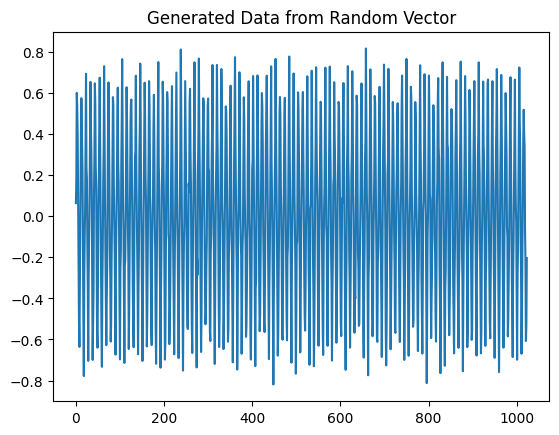

In [13]:
# 오토인코더 클래스 정의
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(data_size, 128), # 입력 데이터를 128 크기로 압축
            nn.ReLU(), # 활성화 함수
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, 3)
        )
        self.decoder = nn.Sequential(
            nn.Linear(3, 12), # 잠재 벡터를 확장
            nn.ReLU(),
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, data_size),
            nn.Tanh()
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#모델, 데이터, 손실함수 및 옵티마이저를 GPU로 이동
model = Autoencoder().to(device)
data = data.unsqueeze(0).to(device)
optimizer = optim.NAdam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# 학습 시작
epochs = 1000
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(data)
    loss = criterion(output, data)
    loss.backward() # 손실에 대한 역전파
    optimizer.step() # 옵티마이저를 통한 파라미터 업데이트

    if (epoch+1) % 100 == 0:
        print(f'Epoch {epoch+1}/{epochs}, Loss: {loss.item()}')

# 임의의 랜덤 벡터 생성
random_vector = torch.randn(1, 3, device = device)

# 디코더를 사용하여 랜덤 벡터로부터 데이터 생성
model.eval() # 모델을 평가 모드로 설정
with torch.no_grad(): # 그래디언트 계산 비활성화
    generated_data = model.decoder(random_vector) # 잠재 벡터로부터 데이터 생성

# 생성된 데이터 시각화
plt.plot(generated_data.cpu().numpy().flatten()) # CPU로 이동 후 시각화
plt.title("Generated Data from Random Vector")
plt.show()

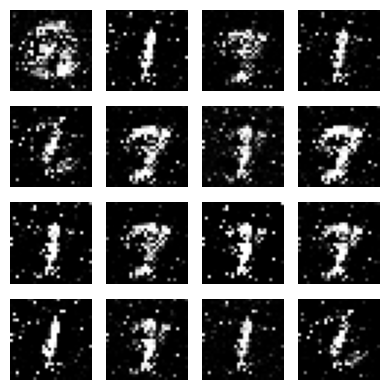

Epoch [1/70], d_loss: 0.3285, g_loss: 2.7224, D(x): 0.89, D(G(z)): 0.16


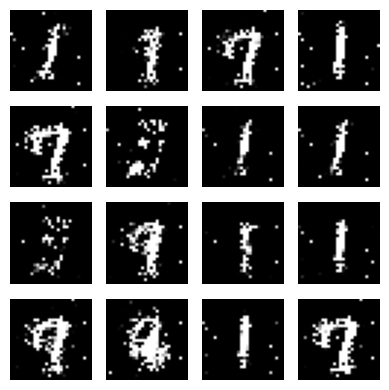

Epoch [2/70], d_loss: 0.2533, g_loss: 3.4393, D(x): 0.94, D(G(z)): 0.14


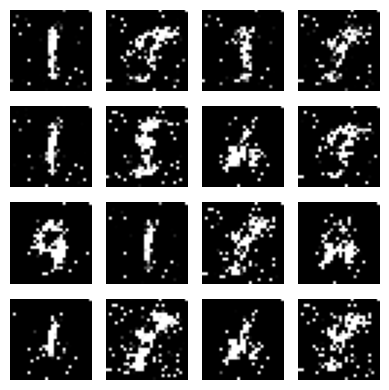

Epoch [3/70], d_loss: 0.0971, g_loss: 3.7897, D(x): 0.99, D(G(z)): 0.08


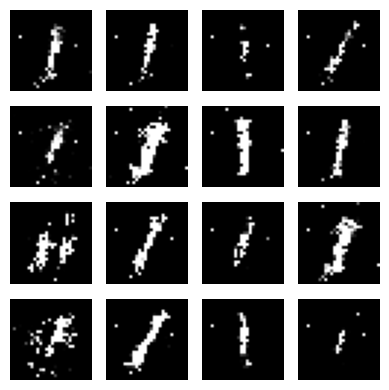

Epoch [4/70], d_loss: 0.4389, g_loss: 3.0979, D(x): 0.89, D(G(z)): 0.18


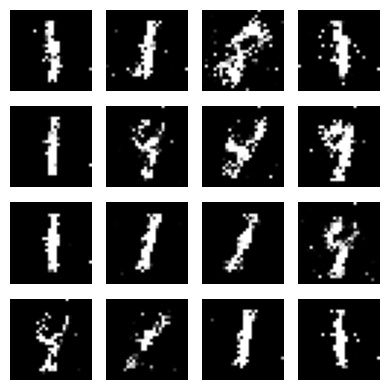

Epoch [5/70], d_loss: 0.4225, g_loss: 2.4512, D(x): 0.87, D(G(z)): 0.14


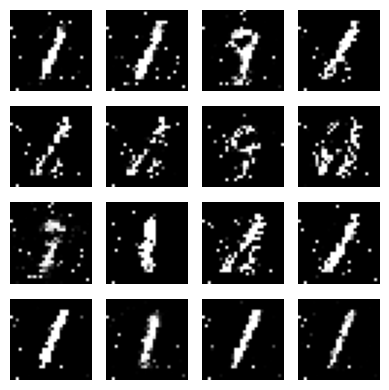

Epoch [6/70], d_loss: 1.1911, g_loss: 1.3204, D(x): 0.50, D(G(z)): 0.05


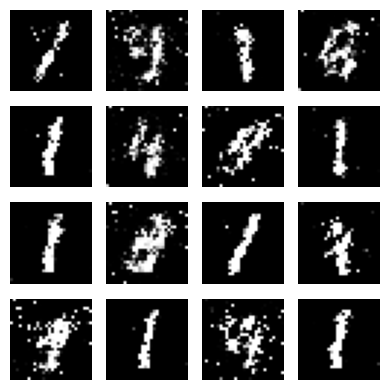

Epoch [7/70], d_loss: 0.6451, g_loss: 1.6279, D(x): 0.74, D(G(z)): 0.16


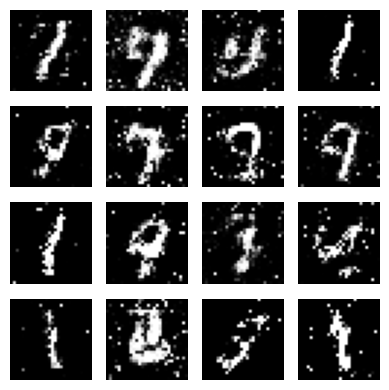

Epoch [8/70], d_loss: 0.8894, g_loss: 1.3420, D(x): 0.63, D(G(z)): 0.20


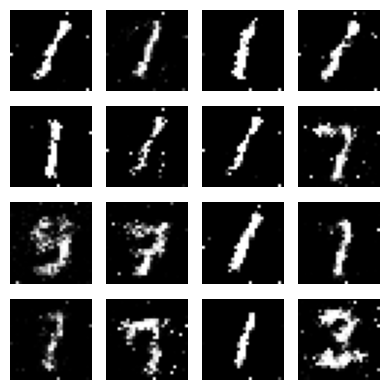

Epoch [9/70], d_loss: 0.7948, g_loss: 1.4280, D(x): 0.70, D(G(z)): 0.22


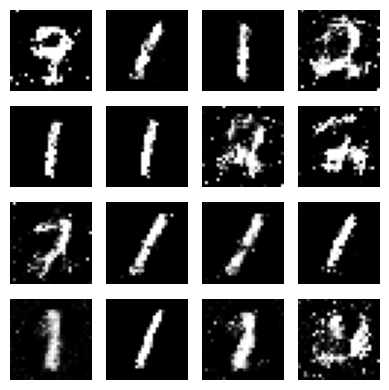

Epoch [10/70], d_loss: 0.9303, g_loss: 1.1793, D(x): 0.59, D(G(z)): 0.17


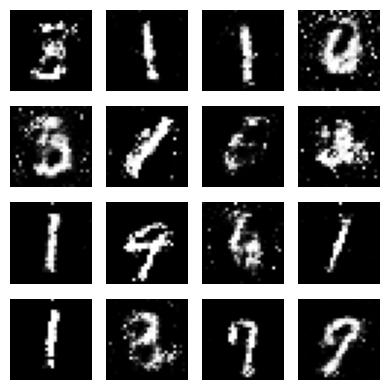

Epoch [11/70], d_loss: 0.8886, g_loss: 1.2228, D(x): 0.67, D(G(z)): 0.26


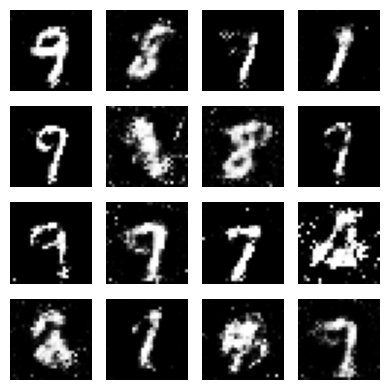

Epoch [12/70], d_loss: 0.6496, g_loss: 1.8438, D(x): 0.74, D(G(z)): 0.20


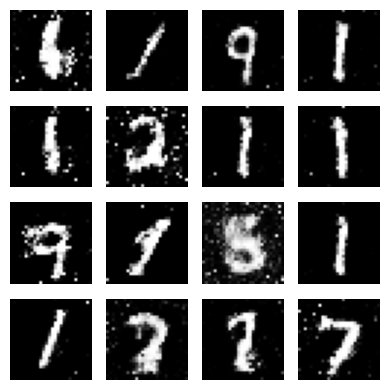

Epoch [13/70], d_loss: 1.0906, g_loss: 1.3621, D(x): 0.66, D(G(z)): 0.34


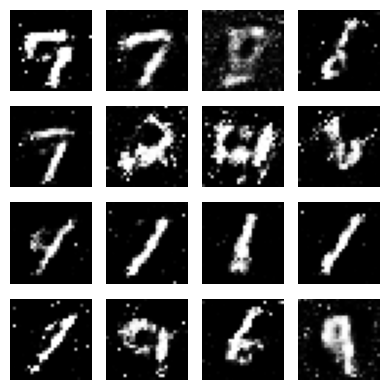

Epoch [14/70], d_loss: 1.0569, g_loss: 0.9734, D(x): 0.57, D(G(z)): 0.24


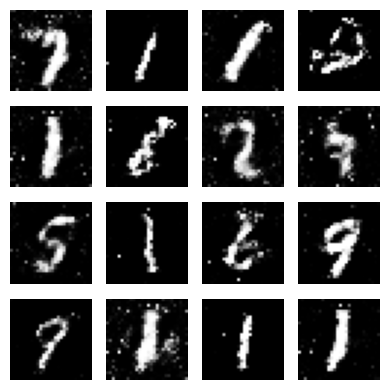

Epoch [15/70], d_loss: 1.0352, g_loss: 1.8367, D(x): 0.71, D(G(z)): 0.40


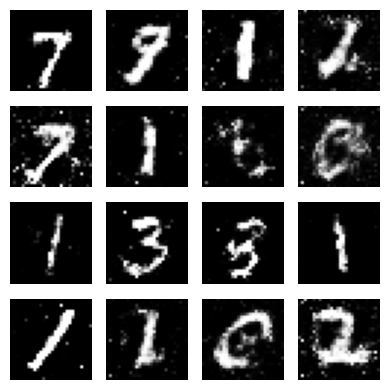

Epoch [16/70], d_loss: 1.0463, g_loss: 1.3588, D(x): 0.63, D(G(z)): 0.31


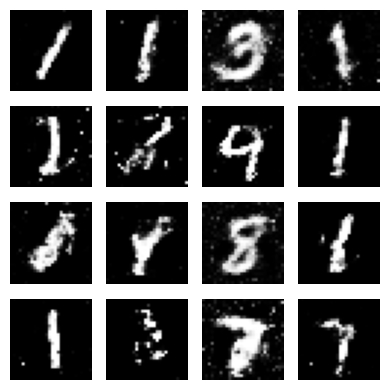

Epoch [17/70], d_loss: 0.9812, g_loss: 1.7750, D(x): 0.71, D(G(z)): 0.38


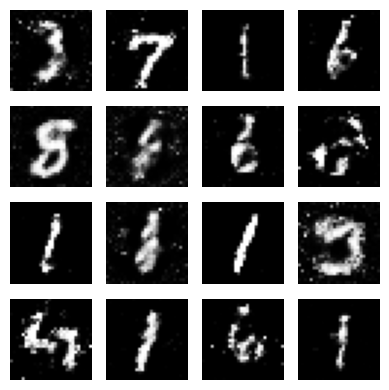

Epoch [18/70], d_loss: 1.0799, g_loss: 1.5645, D(x): 0.74, D(G(z)): 0.47


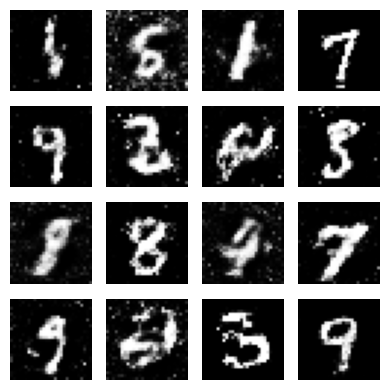

Epoch [19/70], d_loss: 0.9921, g_loss: 2.0761, D(x): 0.81, D(G(z)): 0.46


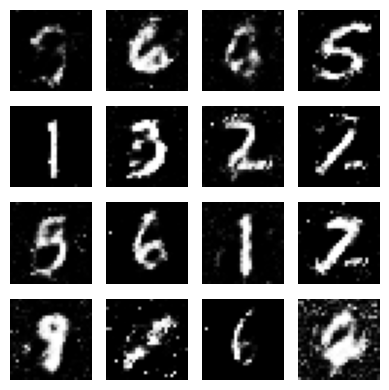

Epoch [20/70], d_loss: 1.1837, g_loss: 1.4238, D(x): 0.66, D(G(z)): 0.41


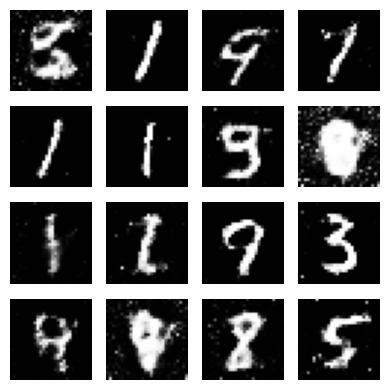

Epoch [21/70], d_loss: 0.8743, g_loss: 1.3216, D(x): 0.74, D(G(z)): 0.37


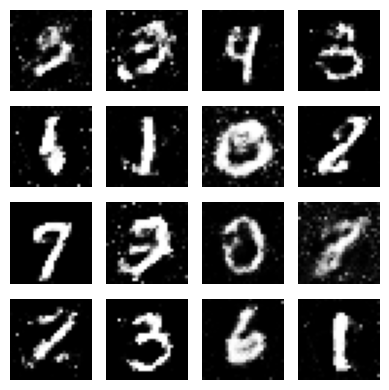

Epoch [22/70], d_loss: 1.0729, g_loss: 1.2806, D(x): 0.59, D(G(z)): 0.28


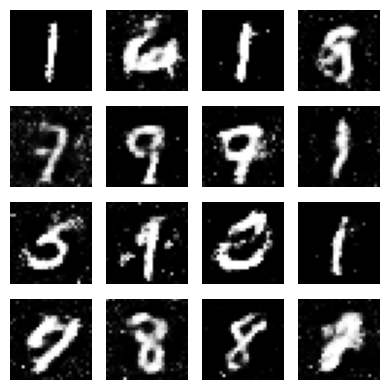

Epoch [23/70], d_loss: 1.0177, g_loss: 1.3942, D(x): 0.62, D(G(z)): 0.31


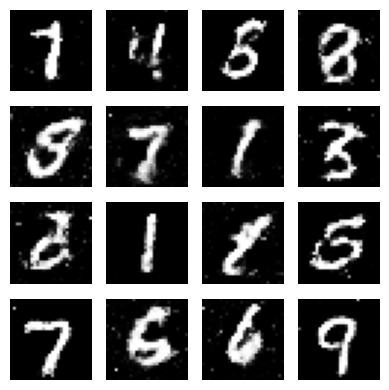

Epoch [24/70], d_loss: 1.0343, g_loss: 2.0066, D(x): 0.80, D(G(z)): 0.46


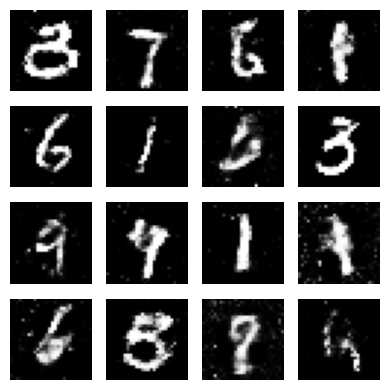

Epoch [25/70], d_loss: 1.0616, g_loss: 1.2470, D(x): 0.58, D(G(z)): 0.31


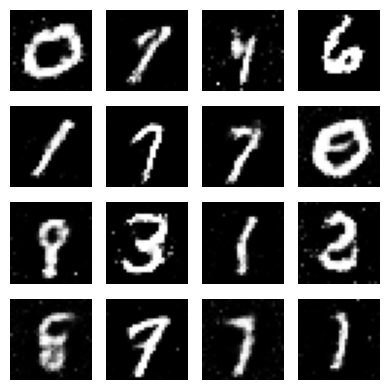

Epoch [26/70], d_loss: 0.9138, g_loss: 1.4414, D(x): 0.65, D(G(z)): 0.31


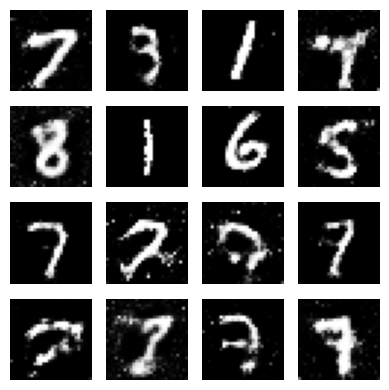

Epoch [27/70], d_loss: 0.9966, g_loss: 1.6805, D(x): 0.71, D(G(z)): 0.37


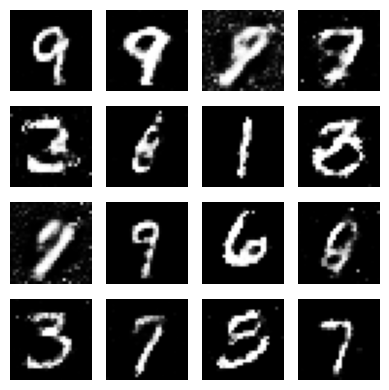

Epoch [28/70], d_loss: 0.9724, g_loss: 1.6246, D(x): 0.65, D(G(z)): 0.34


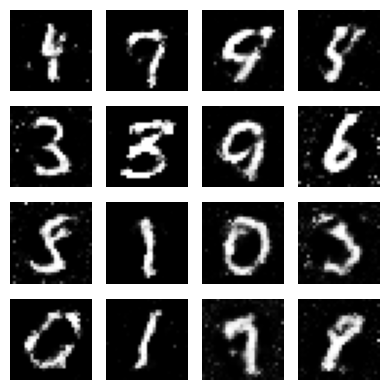

Epoch [29/70], d_loss: 0.9661, g_loss: 1.2784, D(x): 0.64, D(G(z)): 0.30


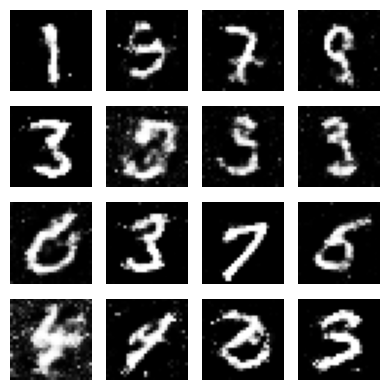

Epoch [30/70], d_loss: 1.1500, g_loss: 1.6550, D(x): 0.69, D(G(z)): 0.46


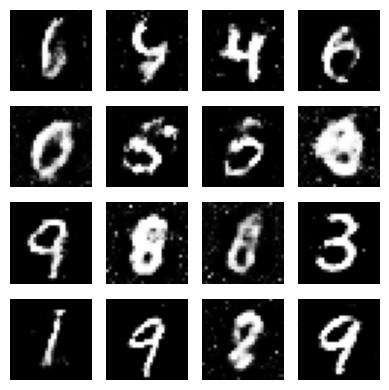

Epoch [31/70], d_loss: 1.1462, g_loss: 1.3319, D(x): 0.62, D(G(z)): 0.37


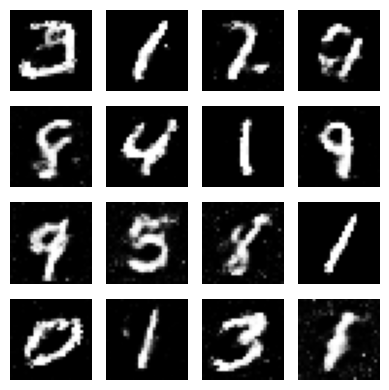

Epoch [32/70], d_loss: 1.1020, g_loss: 1.5141, D(x): 0.62, D(G(z)): 0.37


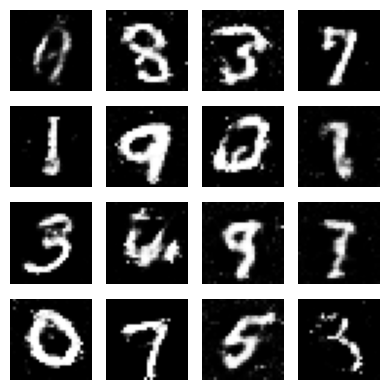

Epoch [33/70], d_loss: 1.0043, g_loss: 0.9581, D(x): 0.59, D(G(z)): 0.27


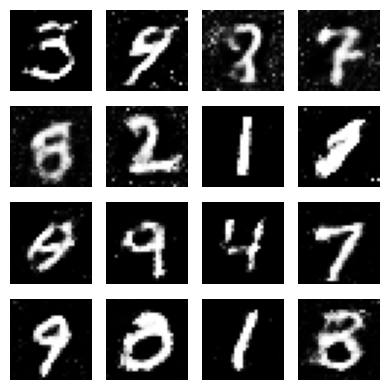

Epoch [34/70], d_loss: 1.0426, g_loss: 1.5260, D(x): 0.61, D(G(z)): 0.31


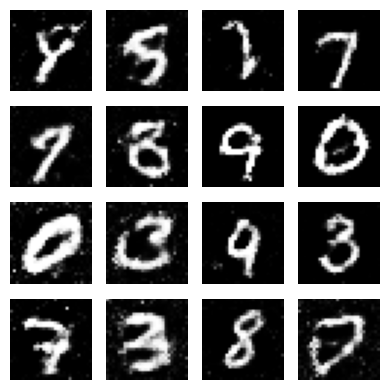

Epoch [35/70], d_loss: 0.8948, g_loss: 1.3508, D(x): 0.71, D(G(z)): 0.32


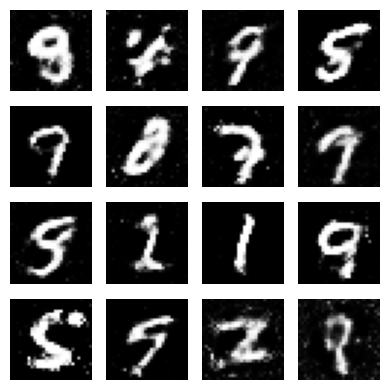

Epoch [36/70], d_loss: 1.1214, g_loss: 0.8864, D(x): 0.52, D(G(z)): 0.27


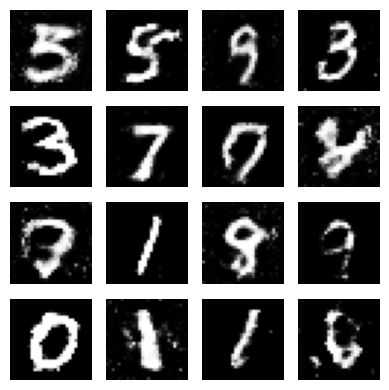

Epoch [37/70], d_loss: 1.0948, g_loss: 1.7209, D(x): 0.72, D(G(z)): 0.44


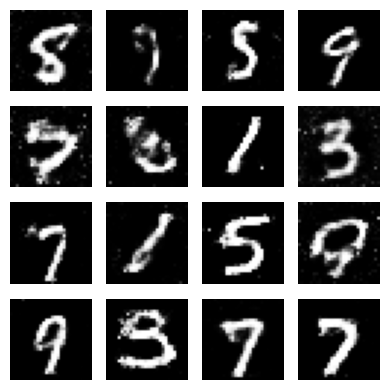

Epoch [38/70], d_loss: 1.2755, g_loss: 1.6308, D(x): 0.70, D(G(z)): 0.46


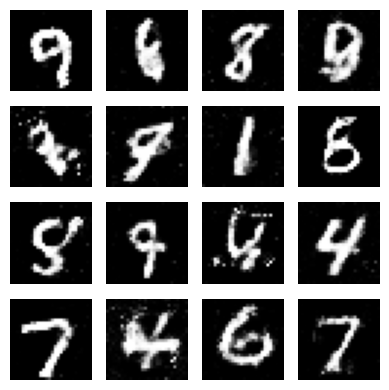

Epoch [39/70], d_loss: 1.0756, g_loss: 1.3519, D(x): 0.67, D(G(z)): 0.39


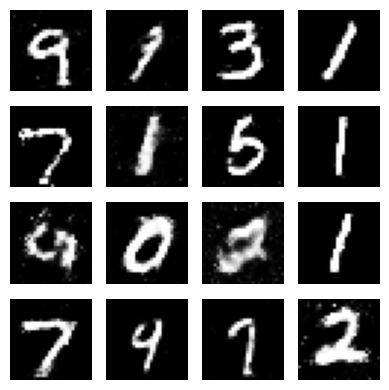

Epoch [40/70], d_loss: 1.2452, g_loss: 1.5246, D(x): 0.59, D(G(z)): 0.39


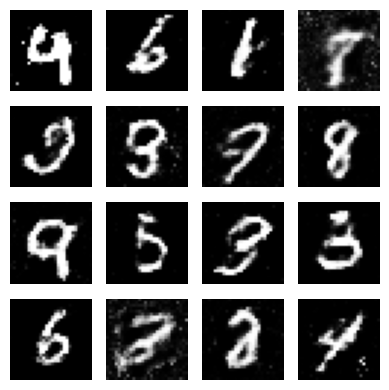

Epoch [41/70], d_loss: 1.0721, g_loss: 0.9762, D(x): 0.57, D(G(z)): 0.31


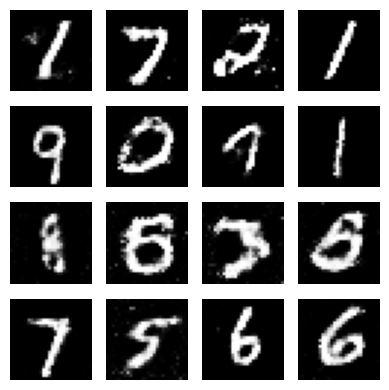

Epoch [42/70], d_loss: 0.8791, g_loss: 1.8091, D(x): 0.73, D(G(z)): 0.34


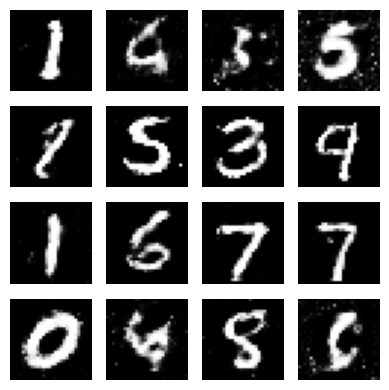

Epoch [43/70], d_loss: 1.0082, g_loss: 1.6928, D(x): 0.75, D(G(z)): 0.41


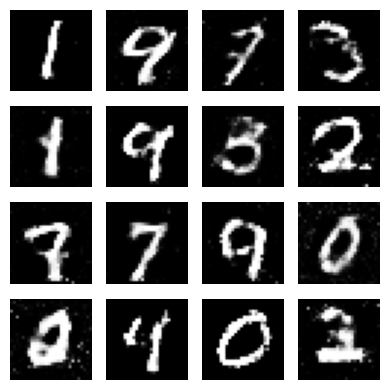

Epoch [44/70], d_loss: 1.1347, g_loss: 1.4046, D(x): 0.66, D(G(z)): 0.43


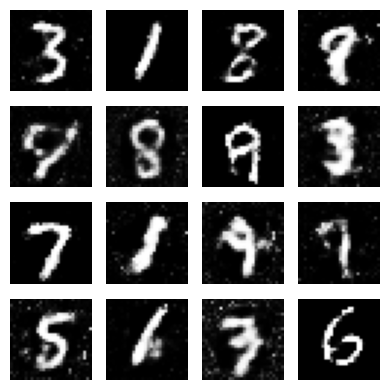

Epoch [45/70], d_loss: 1.0552, g_loss: 1.5108, D(x): 0.67, D(G(z)): 0.38


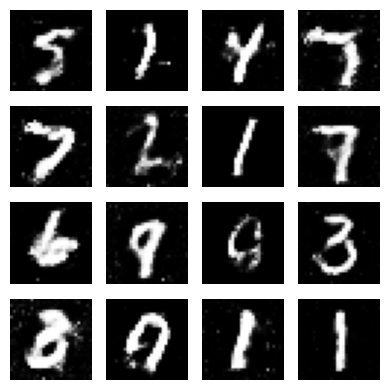

Epoch [46/70], d_loss: 0.8805, g_loss: 1.3346, D(x): 0.64, D(G(z)): 0.26


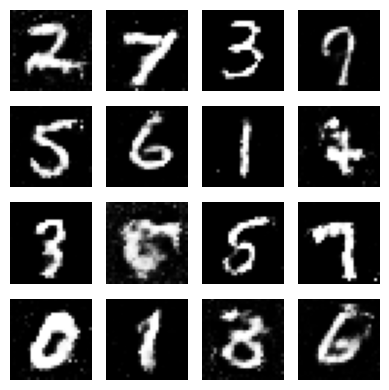

Epoch [47/70], d_loss: 0.9290, g_loss: 0.9465, D(x): 0.61, D(G(z)): 0.25


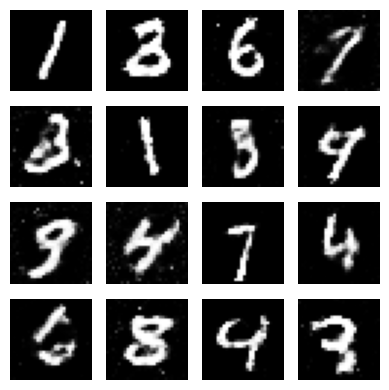

Epoch [48/70], d_loss: 0.9649, g_loss: 1.2186, D(x): 0.70, D(G(z)): 0.41


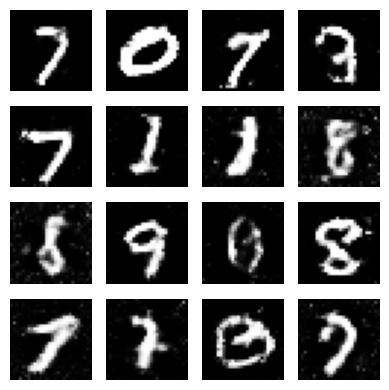

Epoch [49/70], d_loss: 1.1068, g_loss: 1.6944, D(x): 0.67, D(G(z)): 0.41


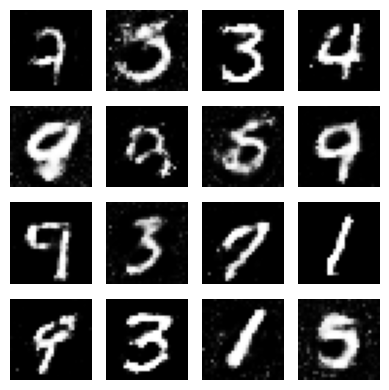

Epoch [50/70], d_loss: 1.1434, g_loss: 1.1815, D(x): 0.61, D(G(z)): 0.37


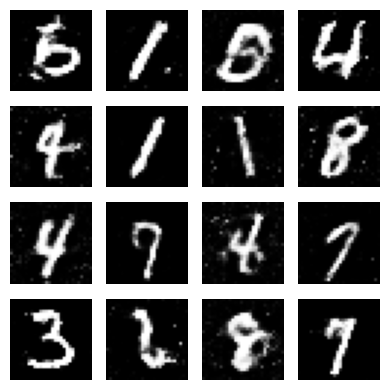

Epoch [51/70], d_loss: 1.0547, g_loss: 1.9130, D(x): 0.71, D(G(z)): 0.45


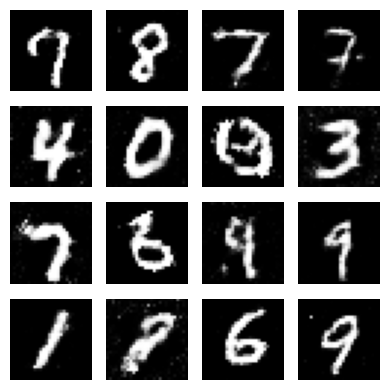

Epoch [52/70], d_loss: 0.9946, g_loss: 1.5996, D(x): 0.74, D(G(z)): 0.38


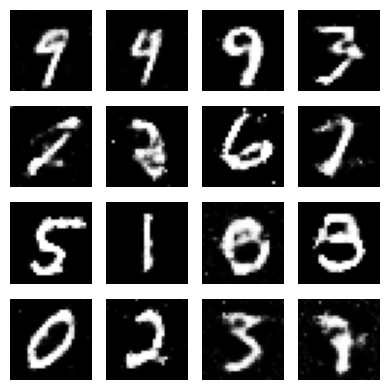

Epoch [53/70], d_loss: 0.9111, g_loss: 1.3603, D(x): 0.71, D(G(z)): 0.33


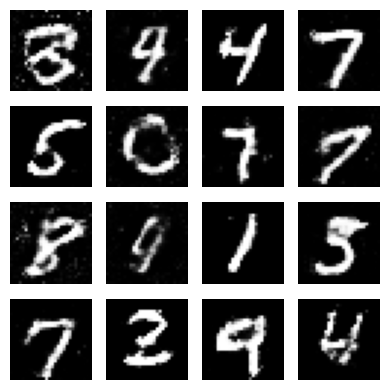

Epoch [54/70], d_loss: 1.1320, g_loss: 1.8195, D(x): 0.74, D(G(z)): 0.47


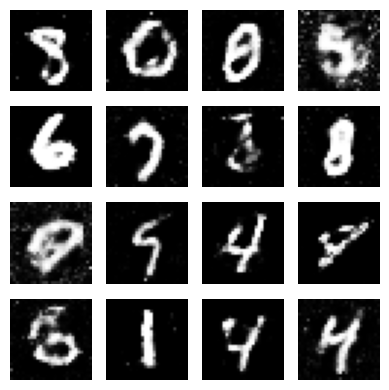

Epoch [55/70], d_loss: 1.0474, g_loss: 1.2609, D(x): 0.63, D(G(z)): 0.37


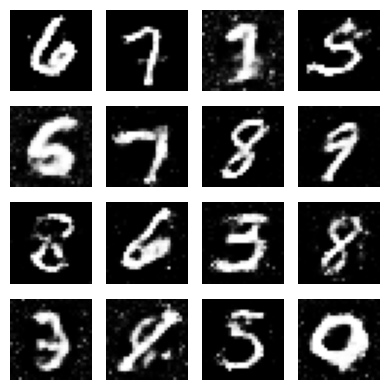

Epoch [56/70], d_loss: 1.1204, g_loss: 1.2120, D(x): 0.61, D(G(z)): 0.38


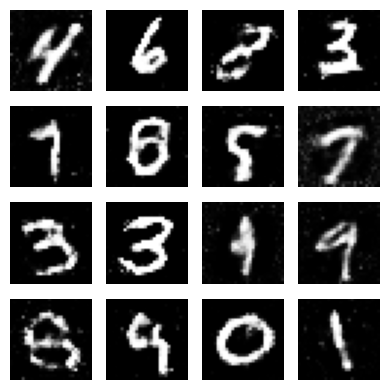

Epoch [57/70], d_loss: 1.1540, g_loss: 1.6403, D(x): 0.57, D(G(z)): 0.35


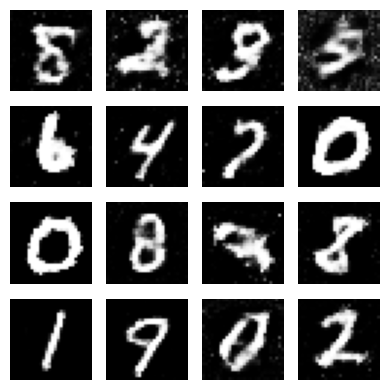

Epoch [58/70], d_loss: 1.0250, g_loss: 1.8773, D(x): 0.69, D(G(z)): 0.37


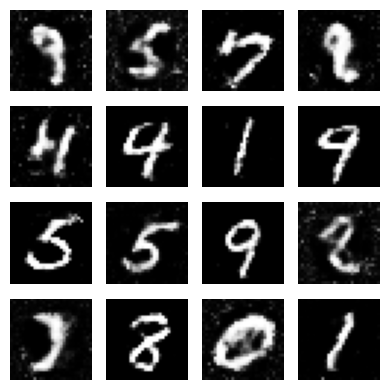

Epoch [59/70], d_loss: 0.9963, g_loss: 2.1248, D(x): 0.76, D(G(z)): 0.44


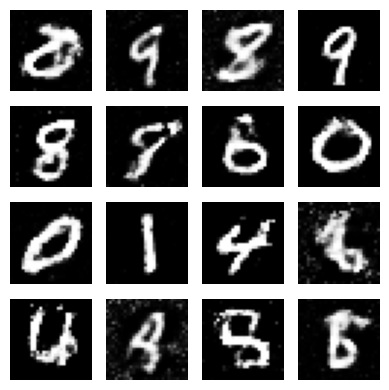

Epoch [60/70], d_loss: 1.3238, g_loss: 1.8909, D(x): 0.59, D(G(z)): 0.40


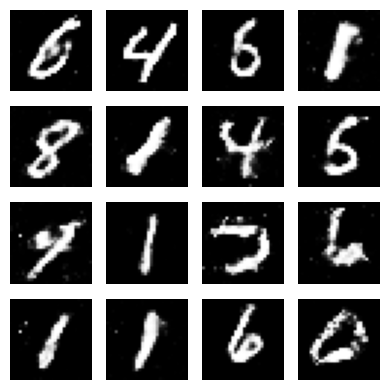

Epoch [61/70], d_loss: 0.9700, g_loss: 0.9690, D(x): 0.56, D(G(z)): 0.22


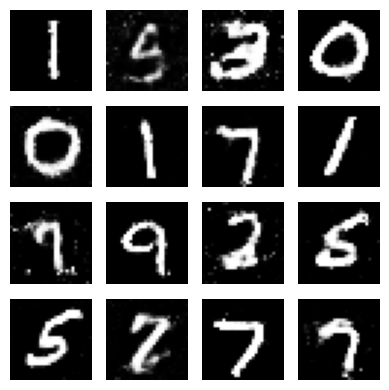

Epoch [62/70], d_loss: 0.9051, g_loss: 1.3985, D(x): 0.72, D(G(z)): 0.37


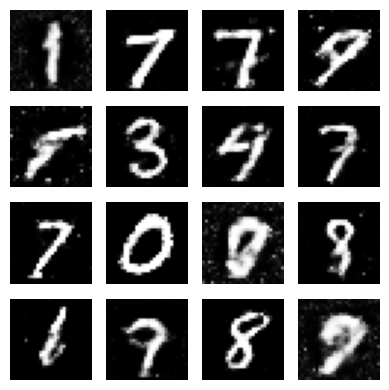

Epoch [63/70], d_loss: 1.2267, g_loss: 1.8395, D(x): 0.73, D(G(z)): 0.48


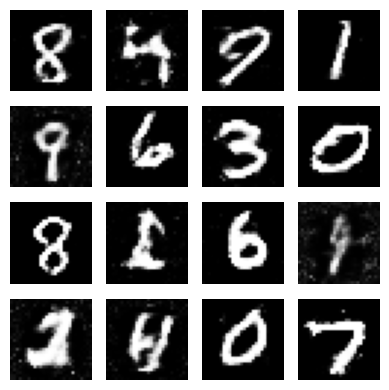

Epoch [64/70], d_loss: 1.0584, g_loss: 1.4569, D(x): 0.66, D(G(z)): 0.38


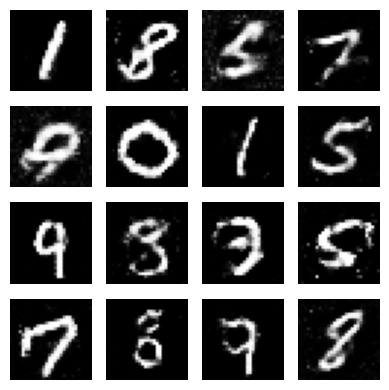

Epoch [65/70], d_loss: 0.8660, g_loss: 1.1965, D(x): 0.64, D(G(z)): 0.27


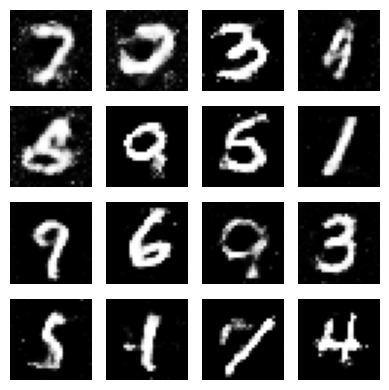

Epoch [66/70], d_loss: 0.8753, g_loss: 1.4241, D(x): 0.69, D(G(z)): 0.28


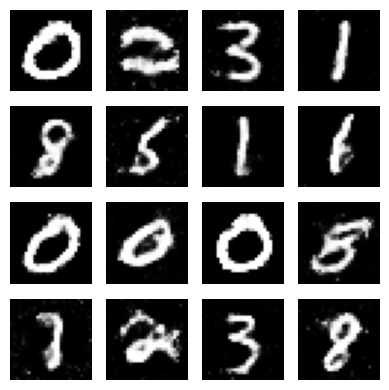

Epoch [67/70], d_loss: 1.2471, g_loss: 0.8909, D(x): 0.49, D(G(z)): 0.29


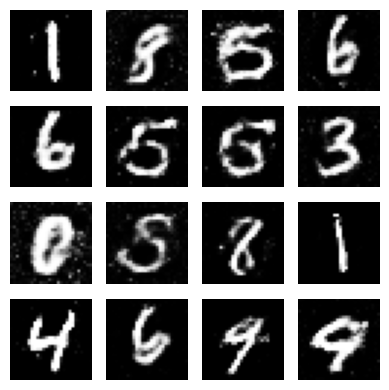

Epoch [68/70], d_loss: 0.9815, g_loss: 1.6316, D(x): 0.73, D(G(z)): 0.39


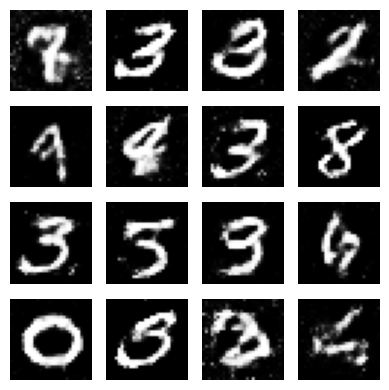

Epoch [69/70], d_loss: 0.9086, g_loss: 1.5227, D(x): 0.64, D(G(z)): 0.25


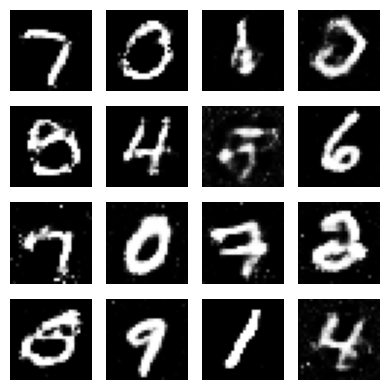

Epoch [70/70], d_loss: 0.8944, g_loss: 1.5789, D(x): 0.72, D(G(z)): 0.32


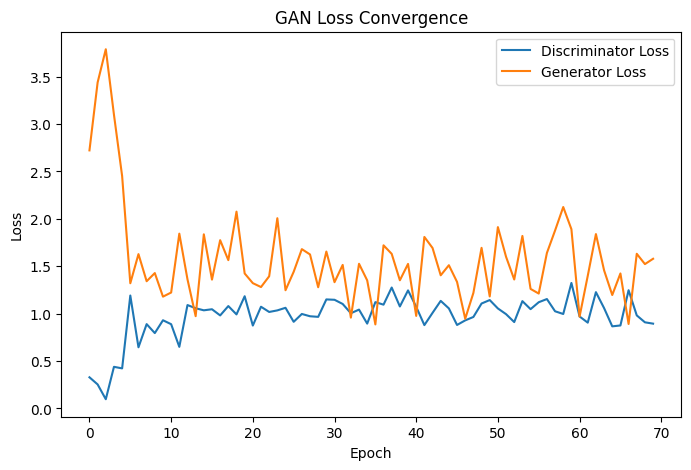

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 데이터 로더 설정
transform =  transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

# 생성자 클래스
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            nn.Linear(1024, 28*28), # 784
            nn.Tanh()
        )
    def forward(self, x):
        return self.model(x).view(x.size(0), 1, 28, 28)

# 판별자 클래스
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)
    
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# 손실 함수 및 옵티마이저
# loss_function = nn.BCELoss()
loss_function = nn.BCELoss()
g_optimizer = optim.NAdam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.NAdam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# 시각화 함수

def show_generated_images(epoch, generator, show=False, save=False, path='output.png'):
    with torch.no_grad():
        noise = torch.randn(16, 100, device=device)
        fake_images = generator(noise)
        fake_images = fake_images.cpu().view(-1, 28, 28) # reshape for plotting
        fig, axs = plt.subplots(4, 4, figsize=(4, 4), sharey=True, sharex=True)
        for i, ax in enumerate(axs.flatten()):
            ax.imshow(fake_images[i],cmap='gray')
            ax.axis('off')
        plt.tight_layout()
        if save:
            plt.savefig(path.format(epoch=epoch))
        if show:
            plt.show()
        plt.close()

# 손실 기록용 리스트
d_losses = []
g_losses = []

# 학습 시작
epochs = 70
for epoch in range(epochs):
    for i, (images, _) in enumerate(train_loader):
        images = images.to(device)
        batch_size = images.size(0)

        real_labels = torch.ones(batch_size, 1, device=device) # [1, 1, 1, 1]
        fake_labels = torch.zeros(batch_size, 1, device=device) # [0, 0, 0, 0]

        # 판별자 훈련
        outputs = discriminator(images)
        d_loss_real = loss_function(outputs, real_labels)
        real_score = outputs

        noise = torch.randn(batch_size, 100, device=device)
        fake_images = generator(noise)
        outputs = discriminator(fake_images.detach())
        d_loss_fake = loss_function(outputs, fake_labels)
        fake_score = outputs

        d_loss = d_loss_real + d_loss_fake
        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        #생성자 훈련
        outputs = discriminator(fake_images)
        g_loss = loss_function(outputs, real_labels) # 1이 많다는거 -> fake를 real로 속였다.

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()
    # 손실값 저장
    d_losses.append(d_loss.item())
    g_losses.append(g_loss.item())
    # 매 에폭 마다 이미지 생성 및 시각화
    show_generated_images(epoch, generator, show=True, save=False)

    print(f'Epoch [{epoch+1}/{epochs}], d_loss: {d_loss.item():.4f}, g_loss: {g_loss.item():.4f}, D(x): {real_score.mean().item():.2f}, D(G(z)): {fake_score.mean().item():.2f}')

# d_loss: 판별자(discriminator)의 손실 값
# g_loss:생성자(generator)의 손실 값
# D(x): 판별자가 실제 이미지를 진짜라고 판단한 평균 확률. 이 값이 1에 가깝다는 것은 판별자가 실제 이미지를 잘 인식하고 있다는 것을 의미
# D(G(z)):판별자가 생성자가 만든 가짜 이미지를 진짜라고 판단한 평균 확률
# -----------------
# 손실 곡선 시각화
# -----------------
plt.figure(figsize=(8, 5))
plt.plot(d_losses, label="Discriminator Loss")
plt.plot(g_losses, label="Generator Loss")
plt.title("GAN Loss Convergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


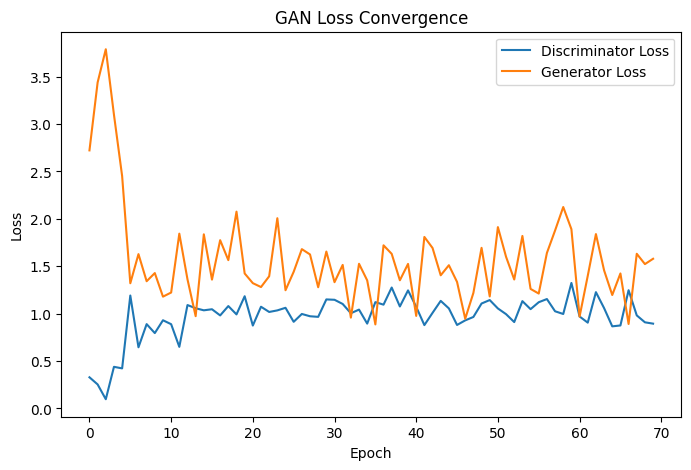

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(d_losses, label="Discriminator Loss")
plt.plot(g_losses, label="Generator Loss")
plt.title("GAN Loss Convergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

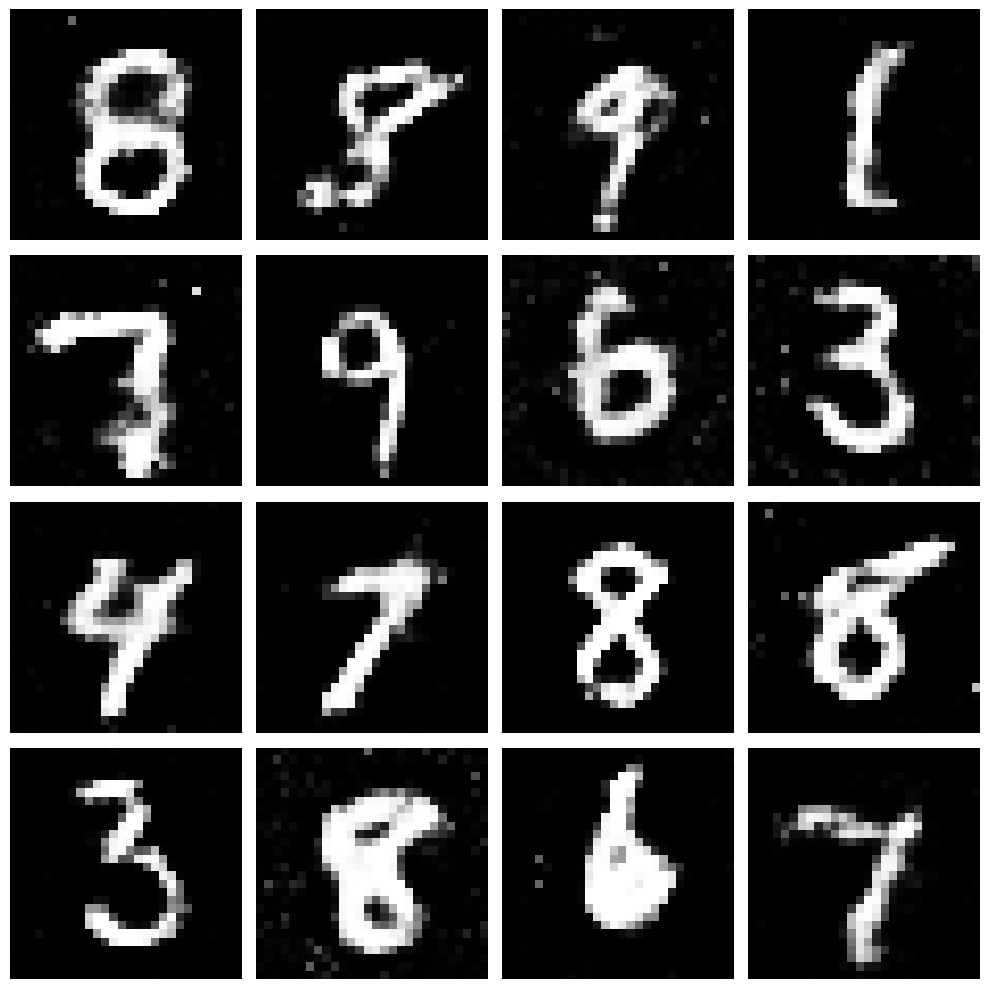

In [41]:
# 임의의 이미지 생성 및 시각화
noise = torch.randn(16, 100, device=device)
fake_images = generator(noise)
fake_images = fake_images.cpu().detach().numpy()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(fake_images[i][0], cmap='gray')
    ax.axis('off')
plt.tight_layout()
plt.show()